In [1]:
import os
import numpy as np
from scipy.fftpack import fft2
import matplotlib.pyplot as plt
from matplotlib import rc
from matplotlib import font_manager
from pathlib import Path
from prf_expect.utils.beh import calculate_visual_angle
from prf_expect.utils import io
from prf_expect.utils.viz import cm_to_inch

In [2]:
cwd = os.getcwd()
font_dirs = [Path(cwd).parent.parent.parent / "arial"]
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)
for font_file in font_files:
    font_manager.fontManager.addfont(font_file)

rc('pdf', fonttype=42, use14corefonts=False)
rc('axes', linewidth=0.5)
rc('font',**{'family':'Arial'})
rc('text', usetex=False)
rc('xtick', labelsize=6)
rc('ytick', labelsize=6)
rc('axes', labelsize=6)
rc('legend', fontsize=6)

plt.rcParams['xtick.major.width'] = 0.5
plt.rcParams['ytick.major.width'] = 0.5
plt.rcParams['xtick.major.size'] = 2
plt.rcParams['ytick.major.size'] = 2
plt.rcParams['xtick.minor.width'] = 0.5
plt.rcParams['ytick.minor.width'] = 0.5
plt.rcParams['xtick.minor.size'] = 1
plt.rcParams['ytick.minor.size'] = 1

In [3]:
figure_result_dir = Path(cwd).parent / "figures"
bar_image_path = Path("./pRFbar_Screenshots275.png")
bar_image = plt.imread(bar_image_path)

In [4]:
# Orientation spectrum in 180° (orientation) space
# Uses fftshift so angles are measured around the DC-centered spectrum, then folds to [-90, 90].
def orientation_spectrum(image_patch, nr_bin):
    # 2D FFT and shift DC to center
    F = fft2(image_patch - np.mean(image_patch))
    P = np.abs(np.fft.fftshift(F))**2  # power spectrum, DC at center
    
    # Polar coordinates (frequency, orientation)
    rows, cols = P.shape
    cy, cx = rows//2, cols//2
    y, x = np.ogrid[:rows, :cols]
    radius = np.sqrt((x-cx)**2 + (y-cy)**2)
    angle = np.arctan2(y-cy, x-cx) * 180/np.pi  # degrees, range [-180, 180]

    # Fold to orientation space: [-90, 90]
    angle_orient = (angle + 90) % 180 - 90
    
    # Bin by orientation (ignore DC/radius=0)
    orient_bins = np.linspace(-90, 90, nr_bin)
    orient_energy = []
    for i in range(len(orient_bins)-1):
        mask = (angle_orient >= orient_bins[i]) & (angle_orient < orient_bins[i+1]) # (radius > 5)
        orient_energy.append(np.sum(P[mask]))
    
    return np.array(orient_energy)


Loading settings from /gpfs/home6/nwang/software/pRF_expect_pub/pRF_expect_analysis/prf_expect/settings.yml


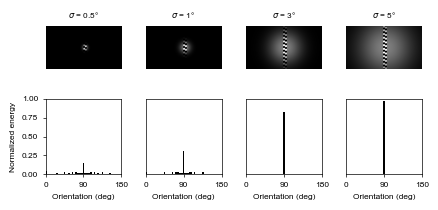

In [5]:
# Compare orientation energy across pRF sizes (degrees) using Gaussian windows centered on image
# Pulls monitor geometry from settings to convert deg → px.
import numpy as np
import matplotlib.pyplot as plt

# Monitor geometry and deg→px conversion
settings = io.load_settings()
screen_size_cm = settings["monitor"]["screen_size_cm"]
screen_size_pix = settings["monitor"]["screen_size_pix"]
distance_to_screen = settings["monitor"]["screen_distance_cm"]
screen_height_deg = calculate_visual_angle(screen_size_cm[1], distance_to_screen)
pixels_per_deg = screen_size_pix[1] / screen_height_deg

# Choose pRF sigmas in degrees (tweak as needed)
prf_sizes_deg = [0.5, 1.0, 3.0, 5.0]
prf_sizes_px = [sigma_deg * pixels_per_deg for sigma_deg in prf_sizes_deg]

# Grayscale bar image
if bar_image.ndim == 3:
    gray = bar_image.mean(axis=2)
else:
    gray = bar_image

# make it binary, make white and black into 1, and gray into 0.5
gray_binary = np.where(gray != np.median(gray), 1, 0)

h, w = gray.shape
cy, cx = h // 2, w // 2 + 30

# Precompute orientation bin centers for plotting (matches orientation_spectrum bins)
nr_bins = 180
orient_edges = np.linspace(0, 180, nr_bins)
orient_centers = (orient_edges[:-1] + orient_edges[1:]) / 2

energy_by_size = []
windowed_samples = []

y, x = np.ogrid[:h, :w]
for sigma_deg, sigma_px in zip(prf_sizes_deg, prf_sizes_px):
    mask = np.exp(-((x - cx) ** 2 + (y - cy) ** 2) / (2 * sigma_px ** 2))
    windowed = gray_binary * mask
    windowed_original = gray * mask
    windowed_samples.append(windowed_original)

    energy = orientation_spectrum(windowed, nr_bins)
    energy_by_size.append(energy / energy.sum())  # normalize for comparison

# Plot windowed images and orientation spectra
fig, axes = plt.subplots(
    2,
    len(prf_sizes_px),
    figsize=cm_to_inch(11.4, 6),
    gridspec_kw={"height_ratios": [1, 1]},
)
for idx, (sigma_deg, sigma_px) in enumerate(zip(prf_sizes_deg, prf_sizes_px)):
    axes[0, idx].imshow(windowed_samples[idx], cmap="gray")
    axes[0, idx].set_title(f"$\sigma$ = {sigma_deg:g}°", fontsize=6)
    axes[0, idx].axis("off")

    # axes[1, idx].plot(orient_centers, energy_by_size[idx], linewidth=0.5, color="k")
    # bar plot of energy by orientation bin
    axes[1, idx].bar(orient_centers, energy_by_size[idx], width=4, color="k", edgecolor="none")
    axes[1, idx].set_xticks([0, 90, 180])
    axes[1, idx].set_xlim(0, 180)
    axes[1, idx].set_ylim(0, 1)
    axes[1, idx].set_xlabel("Orientation (deg)")
    axes[1, idx].set_box_aspect(1)  # make second-row axes roughly square like the images
    if idx==0:
        axes[1, idx].set_ylabel("Normalized energy")
    if idx>0:
        axes[1, idx].set_yticks([])

plt.tight_layout()
fig.savefig(figure_result_dir / f"broadband_orientation_energy.pdf", dpi=600, bbox_inches='tight')
fig.savefig(figure_result_dir / f"broadband_orientation_energy.png", dpi=600, bbox_inches='tight')

In [6]:
# Fraction of orientation energy within ±10° of the bar orientation
# 1) Estimate bar orientation from the full (unwindowed) binary image.
bar_energy = orientation_spectrum(gray_binary, nr_bins)
bar_energy = bar_energy / (bar_energy.sum() + 1e-12)
bar_orientation_deg = orient_centers[np.argmax(bar_energy)]

# 2) Compute orientation distance in 180° orientation space.
def orientation_distance_deg(theta, theta0):
    return np.abs((theta - theta0 + 90) % 180 - 90)

within_10deg = orientation_distance_deg(orient_centers, bar_orientation_deg) <= 10

# 3) Fraction within ±10° for each pRF size.
fraction_within_10deg = [
    float(np.sum(energy[within_10deg])) for energy in energy_by_size
]

print(f"Estimated bar orientation: {bar_orientation_deg:.1f}°")
print("Fraction of orientation energy within ±10° of bar orientation")
for sigma_deg, frac in zip(prf_sizes_deg, fraction_within_10deg):
    print(f"  sigma={sigma_deg:>4.1f}°: {frac:.4f}")

# Optional compact table for downstream use.
import pandas as pd
fraction_df = pd.DataFrame({
    "prf_sigma_deg": prf_sizes_deg,
    "fraction_within_pm10deg": fraction_within_10deg,
})
fraction_df

Estimated bar orientation: 90.0°
Fraction of orientation energy within ±10° of bar orientation
  sigma= 0.5°: 0.3526
  sigma= 1.0°: 0.5720
  sigma= 3.0°: 0.9138
  sigma= 5.0°: 0.9828


,prf_sigma_deg,fraction_within_pm10deg
0,0.5,0.352555
1,1.0,0.572027
2,3.0,0.913755
3,5.0,0.982775


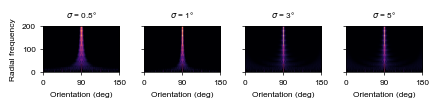

In [7]:


# Orientation–frequency 2D histogram (orientation × radial frequency) for each pRF size
# Clip low/DC and very high frequencies, reduce bin count, and log-scale power to spread dynamic range.
min_r = 0
max_r = 200
freq_bins = np.linspace(min_r, max_r, 30)
orient_bins = np.linspace(0, 180, nr_bins)
energy2d = []

# Recompute windowed binary images (centered Gaussian masks per pRF size)
y, x = np.ogrid[:h, :w]
for sigma_px in prf_sizes_px:
    mask = np.exp(-((x - cx) ** 2 + (y - cy) ** 2) / (2 * sigma_px ** 2))
    windowed = gray_binary * mask

    # FFT power spectrum in polar coords (radius, orientation)
    F = fft2(windowed - np.mean(windowed))
    P = np.abs(np.fft.fftshift(F)) ** 2
    rows, cols = P.shape
    cy_f, cx_f = rows // 2, cols // 2
    yy, xx = np.ogrid[:rows, :cols]
    radius = np.sqrt((xx - cx_f) ** 2 + (yy - cy_f) ** 2)
    angle = np.arctan2(yy - cy_f, xx - cx_f) * 180 / np.pi
    angle_orient = (angle + 90) % 180

    valid = (radius >= min_r) & (radius <= max_r)
    hist2d, _, _ = np.histogram2d(
        angle_orient[valid],
        radius[valid],
        bins=[orient_bins, freq_bins],
        weights=np.log1p(P)[valid],
    )
    # hist2d /= hist2d.sum() + 1e-12
    energy2d.append(hist2d)

# Shared color scale across subplots
vmin = 0.0
vmax = max(h.max() for h in energy2d)

# Plot 2D histograms
fig, axes = plt.subplots(
    1,
    len(prf_sizes_px),
    figsize=cm_to_inch(11.4, 3),
    sharey=True,
)
for idx, hist2d in enumerate(energy2d):
    im = axes[idx].imshow(
        hist2d.T,
        extent=(orient_bins[0], orient_bins[-1], freq_bins[0], freq_bins[-1]),
        aspect="auto",
        origin="lower",
        cmap="magma",
        vmin=vmin,
        vmax=vmax,
    )
    axes[idx].set_title(f"$\\sigma$ = {prf_sizes_deg[idx]:g}°", fontsize=6)
    axes[idx].set_xlabel("Orientation (deg)")
    axes[idx].set_xlim(0, 180)
    axes[idx].set_xticks([0, 90, 180])
    if idx == 0:
        axes[idx].set_ylabel("Radial frequency")

# cbar = fig.colorbar(
#     im,
#     ax=axes.ravel().tolist(),
#     fraction=0.035,
#     pad=0.04,
#     location="right",
# )
# cbar.set_label("Normalized energy (log-weighted)")
fig.tight_layout()
fig.savefig(figure_result_dir / f"broadband_orientation_frequency_energy.pdf", dpi=600, bbox_inches='tight')
fig.savefig(figure_result_dir / f"broadband_orientation_frequency_energy.png", dpi=600, bbox_inches='tight')

Loading settings from /gpfs/home6/nwang/software/pRF_expect_pub/pRF_expect_analysis/prf_expect/settings.yml


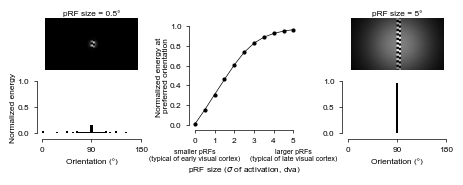

In [8]:
# Compare orientation energy across pRF sizes (degrees) using Gaussian windows centered on image
# Pulls monitor geometry from settings to convert deg → px.
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Monitor geometry and deg→px conversion
settings = io.load_settings()
screen_size_cm = settings["monitor"]["screen_size_cm"]
screen_size_pix = settings["monitor"]["screen_size_pix"]
distance_to_screen = settings["monitor"]["screen_distance_cm"]
screen_height_deg = calculate_visual_angle(screen_size_cm[1], distance_to_screen)
pixels_per_deg = screen_size_pix[1] / screen_height_deg

# Choose pRF sigmas in degrees (tweak as needed)
prf_sizes_deg = [0.00001, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
prf_sizes_px = [sigma_deg * pixels_per_deg for sigma_deg in prf_sizes_deg]

# Grayscale bar image
if bar_image.ndim == 3:
    gray = bar_image.mean(axis=2)
else:
    gray = bar_image

# make it binary, make white and black into 1, and gray into 0.5
gray_binary = np.where(gray != np.median(gray), 1, 0)

h, w = gray.shape
cy, cx = h // 2, w // 2 + 30

# Precompute orientation bin centers for plotting (matches orientation_spectrum bins)
nr_bins = 180
orient_edges = np.linspace(0, 180, nr_bins)
orient_centers = (orient_edges[:-1] + orient_edges[1:]) / 2

energy_by_size = []
windowed_samples = []

y, x = np.ogrid[:h, :w]
for sigma_deg, sigma_px in zip(prf_sizes_deg, prf_sizes_px):
    mask = np.exp(-((x - cx) ** 2 + (y - cy) ** 2) / (2 * sigma_px ** 2))
    windowed = gray_binary * mask
    windowed_original = gray * mask
    windowed_samples.append(windowed_original)

    energy = orientation_spectrum(windowed, nr_bins)
    energy_by_size.append(energy / energy.sum())  # normalize for comparison

# Plot windowed images and orientation spectra
fig = plt.figure(figsize=cm_to_inch(11.4, 4), constrained_layout=False)
outer = fig.add_gridspec(
    1,
    3,
    # width_ratios=[1.2, 2.2, 1.2],
    # wspace=0.35,
)
fig.subplots_adjust(left=0.08, right=0.98, bottom=0.12, top=0.85, wspace=0.55)

left_panel = outer[0].subgridspec(2, 1, height_ratios=[1.0, 1.0], hspace=0.22)
right_panel = outer[2].subgridspec(2, 1, height_ratios=[1.0, 1.0], hspace=0.22)

ax_img_left = fig.add_subplot(left_panel[0, 0])
ax_bar_left = fig.add_subplot(left_panel[1, 0])
ax_merged = fig.add_subplot(outer[1])
ax_img_right = fig.add_subplot(right_panel[0, 0])
ax_bar_right = fig.add_subplot(right_panel[1, 0])

for idx, ax_img, ax_bar in [
    (1, ax_img_left, ax_bar_left),
    (-1, ax_img_right, ax_bar_right),
]:
    sigma_deg = prf_sizes_deg[idx]
    sigma_px = prf_sizes_px[idx]
    ax_img.imshow(windowed_samples[idx], cmap="gray")
    ax_img.set_title(f"pRF size = {sigma_deg:g}°", fontsize=6, pad=2)
    ax_img.axis("off")

    # bar plot of energy by orientation bin
    ax_bar.bar(orient_centers, energy_by_size[idx], width=4, color="k", edgecolor="none")
    ax_bar.set_xticks([0, 90, 180])
    ax_bar.set_xlim(0, 180)
    ax_bar.set_ylim(0, 1)
    ax_bar.set_xlabel("Orientation (°)")
    sns.despine(ax=ax_bar, bottom=True, left=True)
    # ax_bar.set_box_aspect(1)  # keep histogram panel shape close to square

ax_bar_left.set_ylabel("Normalized energy", labelpad=1)
# ax_bar_right.set_ylabel("Normalized energy")
sns.despine(ax=ax_bar_left, offset=4)
sns.despine(ax=ax_bar_right, offset=4)

# ax_bar_right.set_yticks([])

energy_by_size = np.array(energy_by_size)
ax_merged.set_box_aspect(1.0)  # make merged plot square
ax_merged.plot(prf_sizes_deg, energy_by_size[:, 89], marker="o", color="k", markersize=2, linewidth=0.5, clip_on=False)
ax_merged.set_xlabel("pRF size ($\sigma$ of activation, dva)", labelpad=15)
ax_merged.text(0.0, -0.24, "smaller pRFs\n(typical of early visual cortex)", transform=ax_merged.transAxes, ha="center", va="top", fontsize=5)
ax_merged.text(1.0, -0.24, "larger pRFs\n(typical of late visual cortex)", transform=ax_merged.transAxes, ha="center", va="top", fontsize=5)
ax_merged.set_xlim(0, 5)
ax_merged.set_xticks(np.arange(0.0, 5.5, 1))
ax_merged.set_ylim(0, 1)
ax_merged.set_ylabel("Normalized energy at \npreferred orientation", labelpad=0.7)
sns.despine(ax=ax_merged, offset=4)

fig.savefig(figure_result_dir / f"broadband_orientation_energy_final.pdf", dpi=600, bbox_inches='tight')
fig.savefig(figure_result_dir / f"broadband_orientation_energy_final.png", dpi=600, bbox_inches='tight')

## R2-Weighted pRF Size by ROI (Standard Fits)
For each participant and ROI, compute the vertex-wise R2-weighted mean pRF size from the standard final fit, then average those subject-level ROI values across participants.

In [9]:
# R2-weighted pRF size by ROI using standard final-fit parameters
import numpy as np
import pandas as pd
from pathlib import Path
import cortex as cx

from prf_expect.utils import io
from prf_expect.utils.beh import calculate_visual_angle


def _nansem(values):
    vals = np.asarray(values, dtype=float)
    vals = vals[np.isfinite(vals)]
    if vals.size <= 1:
        return np.nan
    return np.nanstd(vals, ddof=1) / np.sqrt(vals.size)


settings = io.load_settings()
data_dir = Path(settings["general"]["data_dir"]) / "data"
space = settings["mri"]["space"]
subjects = list(settings["general"]["subject_list"])

r2_thre = float(globals().get("r2_thre", 0.3))
half_vis_angle = float(
    globals().get(
        "half_vis_angle",
        calculate_visual_angle(
            settings["monitor"]["screen_size_cm"][1],
            settings["monitor"]["screen_distance_cm"],
        )
        / 2,
    )
)

# Use the same combined ROI convention as Untitled-2.ipynb.
if "rois" not in globals():
    ROIs_list_long = (
        "V1",
        "V2",
        "V3",
        "V3A",
        "V3B",
        "V4",
        "LO1",
        "LO2",
        "VO1",
        "VO2",
        "hMT",
        "MST",
        "IPS0",
        "IPS1",
        "IPS2",
        "IPS3",
        "IPS4",
        "IPS5",
    )
    roi_verts = cx.get_roi_verts("fsaverage", ROIs_list_long)
    # rois = {
    #     "V1": roi_verts["V1"],
    #     "V2": roi_verts["V2"],
    #     "V3": roi_verts["V3"],
    #     "V3AB": np.concatenate((roi_verts["V3A"], roi_verts["V3B"])),
    #     "V4": roi_verts["V4"],
    #     "LO": np.concatenate((roi_verts["LO1"], roi_verts["LO2"])),
    #     "TO": np.concatenate((roi_verts["hMT"], roi_verts["MST"])),
    #     "VO": np.concatenate((roi_verts["VO1"], roi_verts["VO2"])),
    #     "earlyIPS": np.concatenate((
    #         roi_verts["IPS0"],
    #         roi_verts["IPS1"],
    #         roi_verts["IPS2"],
    #     )),
    #     "lateIPS": np.concatenate((
    #         roi_verts["IPS3"],
    #         roi_verts["IPS4"],
    #         roi_verts["IPS5"],
    #     )),
    # }
    rois = roi_verts

ROIs_list = list(rois.keys())


def load_subject_standard_params(subject):
    sub_params_dir = (
        data_dir
        / "derivatives"
        / "prf_data"
        / subject
        / "ses-1"
        / "prf_fits"
        / "prf_params"
    )
    final_tsv = sub_params_dir / (
        f"{subject}_ses-1_final-fit_space-{space}_model-norm_stage-iter_desc-prf_params.tsv"
    )

    if not final_tsv.exists():
        raise FileNotFoundError(f"Missing final fit file: {final_tsv}")

    final_df = pd.read_csv(final_tsv, sep="\t")
    required_cols = {"prf_size", "r2", "ecc"}
    missing = sorted(required_cols - set(final_df.columns))
    if missing:
        raise ValueError(f"Missing columns in final fit for {subject}: {missing}")

    prf_size = final_df["prf_size"].to_numpy(dtype=float)
    r2 = final_df["r2"].to_numpy(dtype=float)
    ecc = final_df["ecc"].to_numpy(dtype=float)

    base_mask = (r2 >= r2_thre) & (ecc <= half_vis_angle)
    prf_size[~base_mask] = np.nan
    r2[~base_mask] = np.nan
    return prf_size, r2


subject_rows = []
for subject in subjects:
    prf_size_map, r2_map = load_subject_standard_params(subject)
    n_vertices = prf_size_map.shape[0]

    for roi in ROIs_list:
        verts = rois[roi].astype(int)
        verts = verts[(verts >= 0) & (verts < n_vertices)]
        if verts.size == 0:
            continue

        roi_prf = prf_size_map[verts]
        roi_r2 = r2_map[verts]
        valid = np.isfinite(roi_prf) & np.isfinite(roi_r2) & (roi_r2 > 0)

        if valid.sum() == 0:
            weighted_mean = np.nan
            weight_sum = np.nan
        else:
            weighted_mean = np.average(roi_prf[valid], weights=roi_r2[valid])
            weight_sum = np.nansum(roi_r2[valid])

        subject_rows.append(
            {
                "subject": subject,
                "roi": roi,
                "n_vertices_total": int(verts.size),
                "n_vertices_used": int(valid.sum()),
                "r2_weight_sum": float(weight_sum) if np.isfinite(weight_sum) else np.nan,
                "weighted_prf_size": float(weighted_mean) if np.isfinite(weighted_mean) else np.nan,
            }
        )

subject_roi_prfsize_df = pd.DataFrame(subject_rows)
subject_roi_prfsize_df["roi"] = pd.Categorical(
    subject_roi_prfsize_df["roi"],
    categories=ROIs_list,
    ordered=True,
    )
subject_roi_prfsize_df = subject_roi_prfsize_df.sort_values(
    ["roi", "subject"]
).reset_index(drop=True)

roi_weighted_prfsize_summary_df = (
    subject_roi_prfsize_df.groupby("roi", as_index=False)
    .agg(
        mean_weighted_prf_size=("weighted_prf_size", "mean"),
        sem_weighted_prf_size=("weighted_prf_size", _nansem),
        n_subjects=("subject", "nunique"),
        mean_vertices_used=("n_vertices_used", "mean"),
    )
 )
roi_weighted_prfsize_summary_df["roi"] = pd.Categorical(
    roi_weighted_prfsize_summary_df["roi"],
    categories=ROIs_list,
    ordered=True,
 )
roi_weighted_prfsize_summary_df = roi_weighted_prfsize_summary_df.sort_values(
    "roi"
).reset_index(drop=True)

subject_by_roi_weighted_prfsize = subject_roi_prfsize_df.pivot(
    index="subject", columns="roi", values="weighted_prf_size"
 )

print(
    f"Computed R2-weighted ROI pRF size for "
    f"{subject_roi_prfsize_df['subject'].nunique()} subjects "
    f"across {subject_roi_prfsize_df['roi'].nunique()} ROIs."
)
display(subject_roi_prfsize_df.head(20))
display(roi_weighted_prfsize_summary_df)
display(subject_by_roi_weighted_prfsize)

Loading settings from /gpfs/home6/nwang/software/pRF_expect_pub/pRF_expect_analysis/prf_expect/settings.yml
Computed R2-weighted ROI pRF size for 7 subjects across 18 ROIs.


/scratch-local/68123/ipykernel_495248/1204133011.py:161: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  subject_roi_prfsize_df.groupby("roi", as_index=False)


,subject,roi,n_vertices_total,n_vertices_used,r2_weight_sum,weighted_prf_size
0,sub-001,V1,4377,3059,2074.382258,1.173176
1,sub-002,V1,4377,2041,1403.596242,1.222936
2,sub-004,V1,4377,1951,1218.559293,1.263352
3,sub-005,V1,4377,2171,1430.597743,1.442272
4,sub-007,V1,4377,2599,1917.479806,1.253868
5,sub-009,V1,4377,2310,1614.689549,1.243025
6,sub-012,V1,4377,2470,1812.279398,1.206365
7,sub-001,V2,3956,2810,1917.369459,1.234590
8,sub-002,V2,3956,2065,1448.578939,1.269588
9,sub-004,V2,3956,1579,905.457437,1.348274


,roi,mean_weighted_prf_size,sem_weighted_prf_size,n_subjects,mean_vertices_used
0,V1,1.257856,0.032848,7,2371.571429
1,V2,1.326580,0.036488,7,2165.285714
2,V3,1.505703,0.046050,7,2124.428571
3,V3A,2.198774,0.049216,7,581.714286
4,V3B,2.232619,0.070159,7,697.142857
5,V4,1.690743,0.036738,7,1312.285714
6,LO1,1.919795,0.097475,7,498.142857
7,LO2,2.040635,0.092762,7,765.285714
8,VO1,2.366332,0.063466,7,366.857143
9,VO2,2.784956,0.157292,7,333.857143


roi,V1,V2,V3,V3A,V3B,V4,LO1,LO2,VO1,VO2,hMT,MST,IPS0,IPS1,IPS2,IPS3,IPS4,IPS5
subject,,,,,,,,,,,,,,,,,,
sub-001,1.173176,1.234590,1.537281,2.348229,1.963027,1.788675,1.680978,2.131696,2.619885,3.069234,3.015867,2.914666,2.702493,2.378745,2.249477,2.223278,2.110554,2.049988
sub-002,1.222936,1.269588,1.379256,1.978509,2.189853,1.745413,1.610322,1.825519,2.215717,2.253466,3.090064,4.099356,2.658680,2.977430,3.305361,3.007350,3.306482,4.252038
sub-004,1.263352,1.348274,1.514268,2.188510,2.283892,1.636013,2.069215,2.316586,2.342747,3.187063,3.853138,3.129369,2.749408,3.119170,2.464056,3.143193,3.399150,3.031095
sub-005,1.442272,1.475149,1.607478,2.187306,2.204683,1.770250,1.677681,1.707982,2.514370,3.325890,3.394679,3.143563,2.381801,2.078165,2.145546,2.425596,2.562343,1.711201
sub-007,1.253868,1.296520,1.426765,2.230377,2.302361,1.528013,2.118352,1.872304,2.182579,2.355258,2.750264,3.230134,2.155926,2.492113,2.541110,2.341830,1.918427,1.815935
sub-009,1.243025,1.432760,1.700842,2.347118,2.565767,1.747460,2.259353,2.091154,2.456344,2.678907,3.244751,3.403129,2.345237,2.290587,2.114350,1.906502,2.150054,2.023086
sub-012,1.206365,1.229182,1.374029,2.111367,2.118751,1.619373,2.022665,2.339200,2.232683,2.624872,3.518684,4.051173,2.339025,2.237958,2.213279,2.433173,2.489038,2.672611


Loading settings from /gpfs/home6/nwang/software/pRF_expect_pub/pRF_expect_analysis/prf_expect/settings.yml


,roi,prf_size_mean,prf_size_min,prf_size_max,prf_size_sem,energy_mean,energy_std,n_subjects
0,V1,1.257856,1.173176,1.442272,0.032848,0.386802,0.026555,7
1,V2,1.326580,1.229182,1.475149,0.036488,0.407802,0.029498,7
2,V3,1.505703,1.374029,1.700842,0.046050,0.462088,0.036618,7
3,V3A,2.198774,1.978509,2.348229,0.049216,0.659672,0.033388,7
4,V3B,2.232619,1.963027,2.565767,0.070159,0.667539,0.046268,7
5,V4,1.690743,1.528013,1.788675,0.036738,0.517418,0.028856,7
6,LO1,1.919795,1.610322,2.259353,0.097475,0.582570,0.073188,7
7,LO2,2.040635,1.707982,2.339200,0.092762,0.615964,0.066976,7
8,VO1,2.366332,2.182579,2.619885,0.063466,0.701107,0.040546,7
9,VO2,2.784956,2.253466,3.325890,0.157292,0.780047,0.075923,7


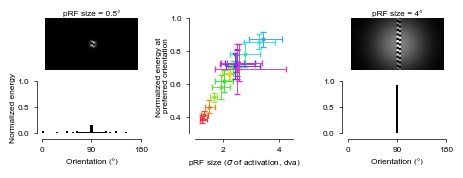

In [10]:
# Compare orientation energy across pRF sizes (degrees) using Gaussian windows centered on image
# Pulls monitor geometry from settings to convert deg -> px.
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.lines import Line2D
from prf_expect.utils.viz import desaturate_palette, sample_cmap

# Monitor geometry and deg->px conversion
settings = io.load_settings()
screen_size_cm = settings["monitor"]["screen_size_cm"]
screen_size_pix = settings["monitor"]["screen_size_pix"]
distance_to_screen = settings["monitor"]["screen_distance_cm"]
screen_height_deg = calculate_visual_angle(screen_size_cm[1], distance_to_screen)
pixels_per_deg = screen_size_pix[1] / screen_height_deg

# Choose pRF sigmas in degrees (tweak as needed)
prf_sizes_deg = [0.00001, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0]
prf_sizes_px = [sigma_deg * pixels_per_deg for sigma_deg in prf_sizes_deg]

# Grayscale bar image
if bar_image.ndim == 3:
    gray = bar_image.mean(axis=2)
else:
    gray = bar_image

# make it binary, make white and black into 1
gray_binary = np.where(gray != np.median(gray), 1, 0)

h, w = gray.shape
cy, cx = h // 2, w // 2 + 30

# Precompute orientation bin centers for plotting (matches orientation_spectrum bins)
nr_bins = 180
orient_edges = np.linspace(0, 180, nr_bins)
orient_centers = (orient_edges[:-1] + orient_edges[1:]) / 2

energy_by_size = []
windowed_samples = []

y, x = np.ogrid[:h, :w]
for sigma_deg, sigma_px in zip(prf_sizes_deg, prf_sizes_px):
    mask = np.exp(-((x - cx) ** 2 + (y - cy) ** 2) / (2 * sigma_px ** 2))
    windowed = gray_binary * mask
    windowed_original = gray * mask
    windowed_samples.append(windowed_original)

    energy = orientation_spectrum(windowed, nr_bins)
    energy_by_size.append(energy / energy.sum())  # normalize for comparison

# Plot windowed images and ROI-summary scatter in middle panel
fig = plt.figure(figsize=cm_to_inch(11.4, 4), constrained_layout=False)
outer = fig.add_gridspec(
    1,
    3,
)
fig.subplots_adjust(left=0.08, right=0.98, bottom=0.12, top=0.85, wspace=0.55)

left_panel = outer[0].subgridspec(2, 1, height_ratios=[1.0, 1.0], hspace=0.22)
right_panel = outer[2].subgridspec(2, 1, height_ratios=[1.0, 1.0], hspace=0.22)

ax_img_left = fig.add_subplot(left_panel[0, 0])
ax_bar_left = fig.add_subplot(left_panel[1, 0])
ax_merged = fig.add_subplot(outer[1])
ax_img_right = fig.add_subplot(right_panel[0, 0])
ax_bar_right = fig.add_subplot(right_panel[1, 0])

for idx, ax_img, ax_bar in [
    (1, ax_img_left, ax_bar_left),
    (-1, ax_img_right, ax_bar_right),
]:
    sigma_deg = prf_sizes_deg[idx]
    ax_img.imshow(windowed_samples[idx], cmap="gray")
    ax_img.set_title(f"pRF size = {sigma_deg:g}°", fontsize=6, pad=2)
    ax_img.axis("off")

    # bar plot of energy by orientation bin
    ax_bar.bar(orient_centers, energy_by_size[idx], width=4, color="k", edgecolor="none")
    ax_bar.set_xticks([0, 90, 180])
    ax_bar.set_xlim(0, 180)
    ax_bar.set_ylim(0, 1)
    ax_bar.set_xlabel("Orientation (°)")
    sns.despine(ax=ax_bar, bottom=True, left=True)

ax_bar_left.set_ylabel("Normalized energy", labelpad=1)
sns.despine(ax=ax_bar_left, offset=4)
sns.despine(ax=ax_bar_right, offset=4)

energy_by_size = np.array(energy_by_size)

# Use preferred-orientation energy curve for ROI mapping
pref_orientation_deg = float(globals().get("bar_orientation_deg", orient_centers[89]))
pref_idx = int(np.argmin(np.abs(orient_centers - pref_orientation_deg)))
pref_energy_curve = energy_by_size[:, pref_idx]

if "subject_roi_prfsize_df" not in globals():
    raise ValueError(
        "Run Cell 11 first to compute subject_roi_prfsize_df before plotting ROI scatter."
    )

# Per-subject ROI values from the weighted pRF size analysis (Cell 11)
roi_subject_df = subject_roi_prfsize_df[["subject", "roi", "weighted_prf_size"]].copy()
roi_subject_df = roi_subject_df[np.isfinite(roi_subject_df["weighted_prf_size"])].copy()
if roi_subject_df.empty:
    raise ValueError("No valid weighted pRF sizes found in subject_roi_prfsize_df.")

size_grid = np.asarray(prf_sizes_deg, dtype=float)
energy_grid = np.asarray(pref_energy_curve, dtype=float)
size_min = float(np.nanmin(size_grid))
size_max = float(np.nanmax(size_grid))

# Map each subject ROI size to corresponding normalized energy on the curve
roi_subject_df["weighted_prf_size_clipped"] = np.clip(
    roi_subject_df["weighted_prf_size"].to_numpy(dtype=float),
    size_min,
    size_max,
)
roi_subject_df["normalized_energy"] = np.interp(
    roi_subject_df["weighted_prf_size_clipped"].to_numpy(dtype=float),
    size_grid,
    energy_grid,
)

def _nansem(values):
    vals = np.asarray(values, dtype=float)
    vals = vals[np.isfinite(vals)]
    if vals.size <= 1:
        return np.nan
    return np.nanstd(vals, ddof=1) / np.sqrt(vals.size)

def _nanstd(values):
    vals = np.asarray(values, dtype=float)
    vals = vals[np.isfinite(vals)]
    if vals.size <= 1:
        return np.nan
    return np.nanstd(vals, ddof=1)

roi_scatter_df = (
    roi_subject_df.groupby("roi", as_index=False, observed=False)
    .agg(
        prf_size_mean=("weighted_prf_size", "mean"),
        prf_size_min=("weighted_prf_size", "min"),
        prf_size_max=("weighted_prf_size", "max"),
        prf_size_sem=("weighted_prf_size", _nansem),
        energy_mean=("normalized_energy", "mean"),
        energy_std=("normalized_energy", _nanstd),
        n_subjects=("subject", "nunique"),
    )
)

valid_roi_order = [roi for roi in ROIs_list if roi in set(roi_scatter_df["roi"])]
roi_scatter_df["roi"] = pd.Categorical(
    roi_scatter_df["roi"],
    categories=valid_roi_order,
    ordered=True,
)
roi_scatter_df = roi_scatter_df.sort_values("roi").reset_index(drop=True)

gist_rainbow_desaturated = desaturate_palette(
    plt.colormaps.get_cmap("gist_rainbow"), saturation=0.80, lightness=0.9
)
gist_rainbow_sampled = sample_cmap(gist_rainbow_desaturated, len(ROIs_list))
roi_color_map = {roi: gist_rainbow_sampled[i] for i, roi in enumerate(ROIs_list)}

for _, row in roi_scatter_df.iterrows():
    roi_name = str(row["roi"])
    roi_color = roi_color_map.get(roi_name, "k")
    x_mean = float(row["prf_size_mean"])
    y_mean = float(row["energy_mean"])
    x_low = max(0.0, x_mean - float(row["prf_size_min"]))
    x_high = max(0.0, float(row["prf_size_max"]) - x_mean)
    y_std = float(row["energy_std"]) if np.isfinite(row["energy_std"]) else 0.0

    ax_merged.errorbar(
        x_mean,
        y_mean,
        xerr=np.array([[x_low], [x_high]], dtype=float),
        yerr=y_std,
        fmt="o",
        markersize=2,
        color=roi_color,
        ecolor=roi_color,
        elinewidth=0.7,
        capsize=2,
        alpha=0.95,
    )

legend_handles = [
    Line2D(
        [],
        [],
        marker="o",
        linestyle="",
        markersize=3,
        color=roi_color_map.get(str(roi), "k"),
        label=str(roi),
    )
    for roi in roi_scatter_df["roi"].astype(str)
]

ax_merged.set_xlabel("pRF size ($\sigma$ of activation, dva)")
ax_merged.set_ylabel("Normalized energy at \npreferred orientation", labelpad=0.7)
ax_merged.set_xlim(1, 4.5)
ax_merged.set_ylim(0.3, 1)
# ax_merged.legend(handles=legend_handles, frameon=False, fontsize=5, title="ROI", title_fontsize=5, ncol=2, loc="lower right")
# ax_merged.set_title("ROI scatter with size range (x) and subject variability (y)", fontsize=6, pad=3)
sns.despine(ax=ax_merged, offset=4)

fig.savefig(
    figure_result_dir / "broadband_orientation_energy_ROIhierarchy.pdf",
    dpi=600,
    bbox_inches="tight",
)
fig.savefig(
    figure_result_dir / "broadband_orientation_energy_ROIhierarchy.png",
    dpi=600,
    bbox_inches="tight",
)

display(roi_scatter_df)